# Sprint 4: Direkte Gehaltsdaten mit Adzuna

## Projekt
Weiterentwicklung der Vorhersage von Gehaltsklassen in Stellenausschreibungen

## Ziel von Sprint 4
In dieser Iteration wird geprüft, ob sich die ursprüngliche Fragestellung mit einer alternativen Datenquelle methodisch verbessern lässt. Dafür wird die Adzuna-API verwendet, da sie Jobanzeigen gemeinsam mit Gehaltsfeldern bereitstellt.

Ziel ist es zunächst nicht, sofort ein neues finales Modell zu trainieren, sondern die Datenquelle zu evaluieren: Wie vollständig sind die Gehaltsfelder, wie konsistent sind die Daten und eignet sich die Quelle für ein stärkeres Machine-Learning-Setup als das bisherige Proxy-Label?

## Importe

In [54]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## API-Zugang

Für die Adzuna-API werden eine `app_id` und ein `app_key` benötigt. Diese Zugangsdaten werden für jede Anfrage als Parameter mitgesendet.

In [55]:
APP_ID = "APP_ID"
APP_KEY = "APP_KEY"

BASE_URL = "https://api.adzuna.com/v1/api/jobs/de/search"

In [117]:
params = {
    "app_id": APP_ID,
    "app_key": APP_KEY,
    "results_per_page": 20,
    "what": "data engineer",
    "content-type": "application/json"
}

response = requests.get(f"{BASE_URL}/1", params=params)

print("Status:", response.status_code)

Status: 200


In [57]:
data = response.json()

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['count', '__CLASS__', 'mean', 'results'])


## Wichtige Felder aus einer Testabfrage extrahieren

Aus den Rohdaten werden zunächst die wichtigsten Felder in einen DataFrame überführt. Dabei interessieren vor allem:
- Jobtitel
- Beschreibung
- Firma
- Ort
- Kategorie
- Gehaltsfelder

In [59]:
jobs = data.get("results", [])

rows = []

for job in jobs:
    row = {
        "id": job.get("id"),
        "title": job.get("title"),
        "description": job.get("description"),
        "salary_min": job.get("salary_min"),
        "salary_max": job.get("salary_max"),
        "salary_is_predicted": job.get("salary_is_predicted"),
        "company": (job.get("company") or {}).get("display_name"),
        "location_display": (job.get("location") or {}).get("display_name"),
        "category_label": (job.get("category") or {}).get("label"),
        "category_tag": (job.get("category") or {}).get("tag"),
        "contract_type": job.get("contract_type"),
        "contract_time": job.get("contract_time"),
        "created": job.get("created")
    }
    rows.append(row)

df_test = pd.DataFrame(rows)

print(df_test.shape)
df_test.head()

(20, 13)


,id,title,description,salary_min,salary_max,salary_is_predicted,company,location_display,category_label,category_tag,contract_type,contract_time,created
0,5654662998,Senior Data Engineer Risiko Regulatorik (w/m/d),BANK.ECHT.ANDERS. Das ist unser Anspruch als A...,None,None,0,TARGOBANK,"Duisburg, Nordrhein-Westfalen",IT-Stellen,it-jobs,NaN,NaN,2026-03-05T06:42:56Z
1,5687566426,Data Engineer Datawarehouse (all genders),"CEWE steht seit 1961 für Innovation, Kreativit...",None,None,0,CEWE Stiftung & Co. KGaA,"Oldenburg, Oldenburg (Kreis)",Unknown,unknown,NaN,NaN,2026-04-02T16:35:10Z
2,5690650706,Senior Full Stack Data Engineer,"At Circonomit, we follow the mission to build ...",None,None,0,Circonomit GmbH,"Köln, Nordrhein-Westfalen",Unknown,unknown,NaN,NaN,2026-04-05T16:16:32Z
3,5685190693,(Senior) Data Engineer (m/f/d) - Azure,p /pp /pp style=text-align:justify /pp style=t...,None,None,0,Riverty Group GmbH,"Tiergarten, Berlin",Unknown,unknown,NaN,NaN,2026-04-01T11:03:52Z
4,5652594281,Data Engineer – Business Intelligence (BI) (f/...,Aufgaben Profil Wir bieten About Us With our s...,None,None,0,"GMX, WEB.DE & mail.com","Karlsruhe, Karlsruhe (Kreis)",Unknown,unknown,NaN,NaN,2026-03-03T18:48:27Z


## Gehaltsfelder der Testabfrage prüfen

Entscheidend ist, wie häufig `salary_min` und `salary_max` tatsächlich vorhanden sind und ob die Gehaltsangaben laut API als prognostiziert markiert sind.

In [60]:
print(df_test[["salary_min", "salary_max", "salary_is_predicted"]].isna().sum())
print()
print(df_test["salary_is_predicted"].value_counts(dropna=False))

salary_min             20
salary_max             20
salary_is_predicted     0
dtype: int64

salary_is_predicted
0    20
Name: count, dtype: int64


In [61]:
df_test[["title", "salary_min", "salary_max", "salary_is_predicted"]].head(20)

,title,salary_min,salary_max,salary_is_predicted
0,Senior Data Engineer Risiko Regulatorik (w/m/d),None,None,0
1,Data Engineer Datawarehouse (all genders),None,None,0
2,Senior Full Stack Data Engineer,None,None,0
3,(Senior) Data Engineer (m/f/d) - Azure,None,None,0
4,Data Engineer – Business Intelligence (BI) (f/...,None,None,0
5,Azure Data Engineer (m/w/d),None,None,0
6,Azure Data Engineer (m/w/d),None,None,0
7,Azure Data Engineer (m/w/d),None,None,0
8,Azure Data Engineer (m/w/d),None,None,0
9,Azure Data Engineer (m/w/d),None,None,0


## Größere Stichprobe laden

Um die Datenquelle besser zu bewerten, werden nun mehrere Suchbegriffe und mehrere Seiten abgefragt.

In [62]:
search_terms = [
    "data engineer",
    "software developer",
    "marketing manager",
    "sales manager",
    "nurse",
    "logistics"
]

all_rows = []

In [63]:
for term in search_terms:
    print("Suche:", term)

    for page in range(1, 150):
        params = {
            "app_id": APP_ID,
            "app_key": APP_KEY,
            "results_per_page": 50,
            "what": term,
            "content-type": "application/json"
        }

        response = requests.get(f"{BASE_URL}/{page}", params=params)

        if response.status_code != 200:
            print("Fehler:", response.status_code, "bei", term, "Seite", page)
            continue

        data = response.json()
        jobs = data.get("results", [])

        for job in jobs:
            row = {
                "id": job.get("id"),
                "title": job.get("title"),
                "description": job.get("description"),
                "salary_min": job.get("salary_min"),
                "salary_max": job.get("salary_max"),
                "salary_is_predicted": job.get("salary_is_predicted"),
                "company": (job.get("company") or {}).get("display_name"),
                "location_display": (job.get("location") or {}).get("display_name"),
                "category_label": (job.get("category") or {}).get("label"),
                "category_tag": (job.get("category") or {}).get("tag"),
                "contract_type": job.get("contract_type"),
                "contract_time": job.get("contract_time"),
                "created": job.get("created"),
                "search_term": term
            }
            all_rows.append(row)

df_adzuna = pd.DataFrame(all_rows)

print(df_adzuna.shape)
df_adzuna.head()

Suche: data engineer
Suche: software developer
Suche: marketing manager
Suche: sales manager
Suche: nurse
Fehler: 503 bei nurse Seite 108
Fehler: 503 bei nurse Seite 110
Fehler: 503 bei nurse Seite 112
Fehler: 503 bei nurse Seite 113
Fehler: 503 bei nurse Seite 114
Fehler: 503 bei nurse Seite 115
Suche: logistics
(20542, 14)


,id,title,description,salary_min,salary_max,salary_is_predicted,company,location_display,category_label,category_tag,contract_type,contract_time,created,search_term
0,5654662998,Senior Data Engineer Risiko Regulatorik (w/m/d),BANK.ECHT.ANDERS. Das ist unser Anspruch als A...,NaN,NaN,0,TARGOBANK,"Duisburg, Nordrhein-Westfalen",IT-Stellen,it-jobs,NaN,NaN,2026-03-05T06:42:56Z,data engineer
1,5687566426,Data Engineer Datawarehouse (all genders),"CEWE steht seit 1961 für Innovation, Kreativit...",NaN,NaN,0,CEWE Stiftung & Co. KGaA,"Oldenburg, Oldenburg (Kreis)",Unknown,unknown,NaN,NaN,2026-04-02T16:35:10Z,data engineer
2,5690650706,Senior Full Stack Data Engineer,"At Circonomit, we follow the mission to build ...",NaN,NaN,0,Circonomit GmbH,"Köln, Nordrhein-Westfalen",Unknown,unknown,NaN,NaN,2026-04-05T16:16:32Z,data engineer
3,5685190693,(Senior) Data Engineer (m/f/d) - Azure,p /pp /pp style=text-align:justify /pp style=t...,NaN,NaN,0,Riverty Group GmbH,"Tiergarten, Berlin",Unknown,unknown,NaN,NaN,2026-04-01T11:03:52Z,data engineer
4,5652594281,Data Engineer – Business Intelligence (BI) (f/...,Aufgaben Profil Wir bieten About Us With our s...,NaN,NaN,0,"GMX, WEB.DE & mail.com","Karlsruhe, Karlsruhe (Kreis)",Unknown,unknown,NaN,NaN,2026-03-03T18:48:27Z,data engineer


## Datenqualität prüfen

Zunächst wird geprüft, wie groß die Stichprobe ist, ob Duplikate vorkommen und wie vollständig die Gehaltsfelder sind.

In [94]:
print("Anzahl Zeilen:", len(df_adzuna))
print("Eindeutige IDs:", df_adzuna["id"].nunique())
print("Duplikate:", len(df_adzuna) - df_adzuna["id"].nunique())

Anzahl Zeilen: 20542
Eindeutige IDs: 15391
Duplikate: 5151


In [95]:
df_adzuna = df_adzuna.drop_duplicates(subset="id").copy()
print(df_adzuna.shape)

(15391, 14)


In [96]:
df_adzuna[["salary_min", "salary_max", "salary_is_predicted"]].isna().sum()

salary_min             14575
salary_max             14578
salary_is_predicted        0
dtype: int64

In [97]:
print("Anteil mit salary_min:",
      round(df_adzuna["salary_min"].notna().mean(), 3))
print("Anteil mit salary_max:",
      round(df_adzuna["salary_max"].notna().mean(), 3))

Anteil mit salary_min: 0.053
Anteil mit salary_max: 0.053


In [98]:
df_adzuna["salary_is_predicted"].value_counts(dropna=False)

salary_is_predicted
0    15391
Name: count, dtype: int64

## Erste Exploration der Adzuna-Daten

Neben der Verfügbarkeit der Gehaltsfelder ist auch interessant, welche Kategorien und Suchbegriffe besonders häufig vorkommen.

In [99]:
df_adzuna["search_term"].value_counts()

search_term
logistics             4911
sales manager         4910
marketing manager     2138
software developer    1516
data engineer         1268
nurse                  648
Name: count, dtype: int64

In [100]:
df_adzuna["category_label"].value_counts().head(15)

category_label
Unknown                                       8792
IT-Stellen                                    1535
Stellen aus PR, Werbung & Marketing           1033
Stellen aus Logistik & Lagerhaltung            921
Vertriebsstellen                               889
Sonstige/Allgemeine Stellen                    648
Stellen für Hochschulabsolventen               341
Beraterstellen                                 190
Stellen aus Gesundheitswesen & Pflege          169
Stellen aus Einzelhandel                       131
Stellen aus Buchhaltung & Finanzwesen          127
Technikerstellen                               100
Stellen aus Gastronomie & Catering              83
Kundendienststellen                             78
Stellen aus Personal & Personalbeschaffung      75
Name: count, dtype: int64

In [101]:
df_adzuna[["title", "company", "location_display", "salary_min", "salary_max", "salary_is_predicted"]].head(20)

,title,company,location_display,salary_min,salary_max,salary_is_predicted
0,Senior Data Engineer Risiko Regulatorik (w/m/d),TARGOBANK,"Duisburg, Nordrhein-Westfalen",NaN,NaN,0
1,Data Engineer Datawarehouse (all genders),CEWE Stiftung & Co. KGaA,"Oldenburg, Oldenburg (Kreis)",NaN,NaN,0
2,Senior Full Stack Data Engineer,Circonomit GmbH,"Köln, Nordrhein-Westfalen",NaN,NaN,0
3,(Senior) Data Engineer (m/f/d) - Azure,Riverty Group GmbH,"Tiergarten, Berlin",NaN,NaN,0
4,Data Engineer – Business Intelligence (BI) (f/...,"GMX, WEB.DE & mail.com","Karlsruhe, Karlsruhe (Kreis)",NaN,NaN,0
5,Azure Data Engineer (m/w/d),netgo group GmbH,"Berlin, Deutschland",NaN,NaN,0
6,Azure Data Engineer (m/w/d),netgo group GmbH,"Köln, Nordrhein-Westfalen",NaN,NaN,0
7,Azure Data Engineer (m/w/d),netgo group GmbH,"Hamburg, Deutschland",NaN,NaN,0
8,Azure Data Engineer (m/w/d),netgo group GmbH,"München, München (Kreis)",NaN,NaN,0
9,Azure Data Engineer (m/w/d),netgo group GmbH,"Frankfurt am Main, Hessen",NaN,NaN,0


## Nur Anzeigen mit Gehaltsangaben weiterverwenden

Für ein stärkeres Gehalts-Setup sind vor allem die Anzeigen relevant, bei denen sowohl `salary_min` als auch `salary_max` vorhanden sind.

In [102]:
df_salary_ready = df_adzuna.dropna(subset=["salary_min", "salary_max"]).copy()

print(df_salary_ready.shape)
df_salary_ready[["title", "salary_min", "salary_max", "salary_is_predicted"]].head(10)

(813, 14)


,title,salary_min,salary_max,salary_is_predicted
35,Data Engineer,176.0,77500.0,0
38,Data Engineer,80000.0,190000.0,0
40,Data Engineer,60000.0,100000.0,0
58,"Data Engineer, Senior",176.0,77500.0,0
59,Data Engineer (gn),70000.0,90000.0,0
76,Cloud & Data Engineer (gn),60000.0,80000.0,0
80,Cloud & Data Engineer (gn),70000.0,80000.0,0
99,Data Engineer (m/w/d),50000.0,75000.0,0
103,Data Engineer Datawarehouse (all genders),50000.0,70000.0,0
106,Data Engineer (m/w/d),60000.0,64800.0,0


## Plausibilitätsbereinigung der Gehaltswerte

Die Anzeigen mit vorhandenen Gehaltsfeldern werden im nächsten Schritt grob auf Plausibilität geprüft. Hintergrund ist, dass in der Stichprobe einzelne sehr kleine oder sehr große Werte auftreten, die auf fehlerhafte oder uneinheitliche Angaben hindeuten können.

Ziel ist hier keine perfekte Bereinigung, sondern eine einfache und nachvollziehbare Qualitätskontrolle der direkten Salary-Daten.

In [103]:
print("Anzahl Zeilen vor Bereinigung:", len(df_salary_ready))

print("Unplausibel kleine salary_min-Werte (<= 1000):",
      (df_salary_ready["salary_min"] <= 1000).sum())

print("Unplausibel große salary_max-Werte (> 250000):",
      (df_salary_ready["salary_max"] > 250000).sum())

print("Fälle mit salary_min > salary_max:",
      (df_salary_ready["salary_min"] > df_salary_ready["salary_max"]).sum())

Anzahl Zeilen vor Bereinigung: 813
Unplausibel kleine salary_min-Werte (<= 1000): 173
Unplausibel große salary_max-Werte (> 250000): 4
Fälle mit salary_min > salary_max: 0


In [104]:
problem_cases = df_salary_ready[
    (df_salary_ready["salary_min"] <= 1000) |
    (df_salary_ready["salary_max"] > 250000) |
    (df_salary_ready["salary_min"] > df_salary_ready["salary_max"])
].copy()

print(problem_cases.shape)
problem_cases[["title", "salary_min", "salary_max", "salary_is_predicted"]].head(20)

(176, 14)


,title,salary_min,salary_max,salary_is_predicted
35,Data Engineer,176.0,77500.0,0
58,"Data Engineer, Senior",176.0,77500.0,0
797,"Senior DevOps Engineer - Highload, Cloud & Dat...",5.0,8.0,0
827,AI Delivery Manager,257.0,112800.0,0
1052,Full-stack Developer,70.0,110.0,0
1124,Field Operations Manager (German-speaking),40.0,55.0,0
1125,Field Operations Manager (German-speaking),40.0,55.0,0
1235,Product Manager - Space,208.0,130000.0,0
1367,Senior Software Developer,50.0,70.0,0
1659,Software Developer Cloud Services (m/w/d) .Net...,0.0,4700.0,0


Für die weitere Analyse werden nun einfache Plausibilitätsregeln verwendet. Entfernt werden:

- Fälle mit sehr kleinen `salary_min`-Werten
- Fälle mit extrem großen `salary_max`-Werten
- Fälle, in denen `salary_min` größer als `salary_max` ist

Die gewählten Schwellenwerte sind pragmatisch und dienen vor allem dazu, offensichtliche Ausreißer aus der Analyse zu entfernen.

In [105]:
df_salary_clean = df_salary_ready[
    (df_salary_ready["salary_min"] > 1000) &
    (df_salary_ready["salary_max"] <= 250000) &
    (df_salary_ready["salary_min"] <= df_salary_ready["salary_max"])
].copy()

print("Anzahl Zeilen nach Bereinigung:", len(df_salary_clean))

Anzahl Zeilen nach Bereinigung: 637


In [106]:
comparison = pd.DataFrame({
    "Datensatz": ["Vor Bereinigung", "Nach Bereinigung"],
    "Anzahl_Zeilen": [len(df_salary_ready), len(df_salary_clean)]
})

comparison

,Datensatz,Anzahl_Zeilen
0,Vor Bereinigung,813
1,Nach Bereinigung,637


Die Plausibilitätsbereinigung zeigt, wie stark die direkte Salary-Quelle von Ausreißern und uneinheitlichen Angaben betroffen ist. Gleichzeitig bleibt sichtbar, ob trotz dieser Einschränkungen noch genügend Fälle für eine weiterführende Analyse vorhanden sind.

## Erstes numerisches Gehaltsziel ableiten

Wenn sowohl `salary_min` als auch `salary_max` vorhanden sind, kann daraus ein mittlerer Gehaltswert berechnet werden. Dieser Wert dient als erste einfache Zielvariable.

In [107]:
df_salary_clean["salary_mid"] = (
    df_salary_clean["salary_min"] + df_salary_clean["salary_max"]
) / 2

df_salary_clean[["title", "salary_min", "salary_max", "salary_mid"]].head()

,title,salary_min,salary_max,salary_mid
38,Data Engineer,80000.0,190000.0,135000.0
40,Data Engineer,60000.0,100000.0,80000.0
59,Data Engineer (gn),70000.0,90000.0,80000.0
76,Cloud & Data Engineer (gn),60000.0,80000.0,70000.0
80,Cloud & Data Engineer (gn),70000.0,80000.0,75000.0


## Verteilung der Gehaltswerte untersuchen

In [108]:
df_salary_clean["salary_mid"].describe()

count       637.000000
mean      58059.277865
std       26447.690878
min        2000.000000
25%       45000.000000
50%       57200.000000
75%       70000.000000
max      200000.000000
Name: salary_mid, dtype: float64

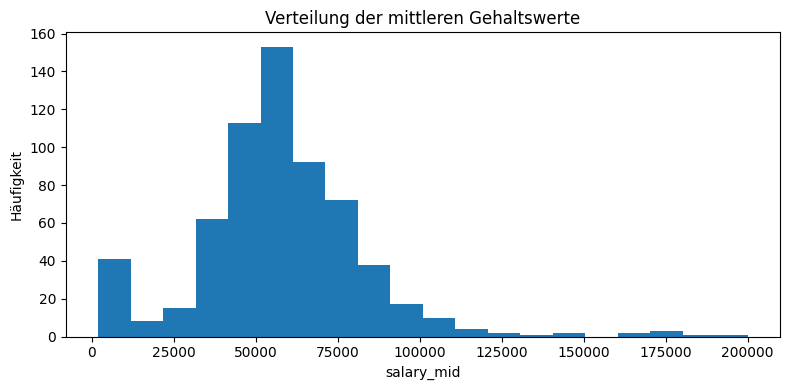

In [109]:
plt.figure(figsize=(8, 4))
plt.hist(df_salary_clean["salary_mid"], bins=20)
plt.title("Verteilung der mittleren Gehaltswerte")
plt.xlabel("salary_mid")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()

## Erste Gehaltsklassen erzeugen

Zusätzlich zum numerischen Ziel kann auch wieder eine grobere Klassifikation erzeugt werden. Dadurch lässt sich prüfen, ob sich aus den Adzuna-Daten auch ein direktes Klassen-Setup aufbauen lässt.

In [110]:
df_salary_clean["salary_class"] = pd.qcut(
    df_salary_clean["salary_mid"],
    q=3,
    labels=["niedrig", "mittel", "hoch"]
)

df_salary_clean["salary_class"].value_counts()

salary_class
mittel     219
niedrig    215
hoch       203
Name: count, dtype: int64

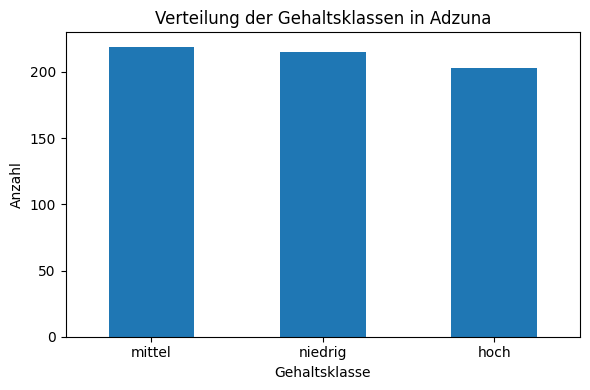

In [111]:
plt.figure(figsize=(6, 4))
df_salary_clean["salary_class"].value_counts().plot(kind="bar")
plt.title("Verteilung der Gehaltsklassen in Adzuna")
plt.xlabel("Gehaltsklasse")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Bewertung der Datenquelle

An dieser Stelle wird bewertet, ob die Adzuna-Daten für eine Weiterentwicklung des Projekts geeignet sind.

Wichtige Fragen:
- Sind ausreichend viele Stellenanzeigen mit Gehaltsangaben vorhanden?
- Sind die Gehaltsangaben plausibel?
- Ist der Anteil an fehlenden Werten vertretbar?
- Wie häufig sind die Gehaltswerte als prognostiziert markiert?

In [112]:
print("Anzahl aller Adzuna-Anzeigen:", len(df_adzuna))
print("Anzahl Anzeigen mit salary_min und salary_max:", len(df_salary_ready))
print("Anzahl Anzeigen nach Plausibilitätsbereinigung:", len(df_salary_clean))

print("Anteil mit Gehaltsfeldern:",
      round(len(df_salary_ready) / len(df_adzuna), 3) if len(df_adzuna) > 0 else 0)

print("Anteil nach Bereinigung:",
      round(len(df_salary_clean) / len(df_adzuna), 3) if len(df_adzuna) > 0 else 0)

Anzahl aller Adzuna-Anzeigen: 15391
Anzahl Anzeigen mit salary_min und salary_max: 813
Anzahl Anzeigen nach Plausibilitätsbereinigung: 637
Anteil mit Gehaltsfeldern: 0.053
Anteil nach Bereinigung: 0.041


In [113]:
df_salary_clean["salary_is_predicted"].value_counts(dropna=False)

salary_is_predicted
0    637
Name: count, dtype: int64

## Datensatz speichern

Falls die Datenqualität ausreichend ist, wird ein erster bereinigter Adzuna-Datensatz für mögliche weitere Analysen gespeichert.

In [114]:
df_salary_clean.to_csv("../data/adzuna_salary_clean.csv", index=False)
print("Datensatz gespeichert als adzuna_salary_clean.csv")

Datensatz gespeichert als adzuna_salary_clean.csv


## Fazit von Sprint 4

Sprint 4 dient als methodische Weiterentwicklung des bisherigen Projekts. Während in den ersten drei Sprints eine Proxy-Gehaltsklasse auf Basis externer Entgeltdaten konstruiert wurde, prüft dieser Sprint, ob sich mit Adzuna eine Datenquelle nutzen lässt, die Jobanzeigen und Gehaltsangaben direkt gemeinsam enthält.

Die Analyse zeigt, dass Adzuna grundsätzlich direkte Gehaltsfelder bereitstellt und damit methodisch näher an der ursprünglichen Fragestellung liegt. Gleichzeitig ist die Datenquelle jedoch deutlich lückenhafter als das bisherige BA-Setup. Nur ein kleiner Teil der Stellenanzeigen enthält sowohl `salary_min` als auch `salary_max`. Zusätzlich treten Ausreißer und potenziell uneinheitliche Gehaltsangaben auf, weshalb eine einfache Plausibilitätsbereinigung notwendig war.

Damit erweist sich Adzuna als interessante, aber praktisch eingeschränkte Erweiterung des Projekts. Die Datenquelle ist geeignet, um die Grenzen und Potenziale eines direkteren Gehaltsansatzes zu untersuchen. Für ein vollständiges Ersetzen des bisherigen Proxy-Setups wäre jedoch eine höhere Abdeckung und eine stabilere Gehaltsqualität wünschenswert.